In [1]:
import numpy as np 
from scipy import stats, linalg
import matplotlib.pyplot as plt

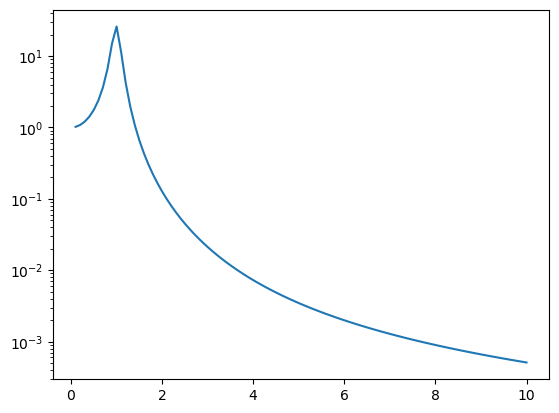

In [2]:
k = 1 
m = 1 
zeta = 0.1 
c = zeta*2*np.sqrt(k*m)

def frf(w):
    num = k+1.0j*w*c
    den = (k-m*w*w)+1.0j*w*c 
    return num/den

try_freq = np.linspace(0.1, 10, 100)
junk = frf(try_freq)
plt.semilogy(try_freq, np.abs(junk)*np.abs(junk))

Based on this result we make the assumption that the PSD of the output process is captured between (-10, 10) . Bandwidth Omega = 20 

Also we choose N = 1024 

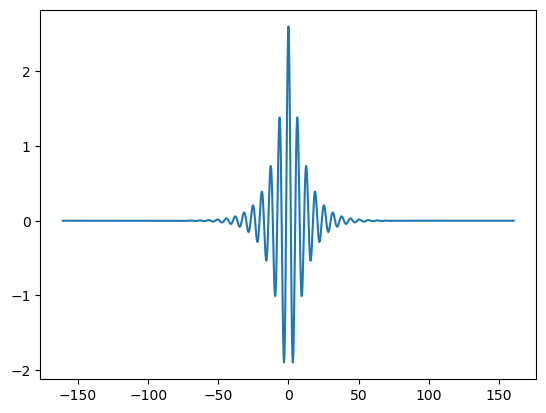

In [17]:
N = 1024 
Omega = 20 

dw = Omega/N 
dt = 2*np.pi/Omega

wvec = (np.arange(-N/2, N/2, 1))*dw 
Syy = (np.abs(frf(wvec)))**2 



Syy2 = np.fft.fftshift(Syy)

Ryy2 = np.fft.ifft(Syy2)*(Omega/(2*np.pi))
Ryy = np.fft.fftshift(Ryy2)
tvec = (np.arange(-N/2, N/2, 1))*dt

plt.plot(tvec, np.real(Ryy))


Verify that the correlation is an even function in time 

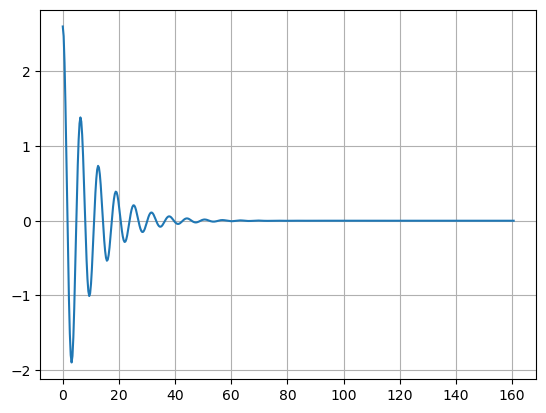

In [4]:
Ryy_half = np.real(Ryy[int(N/2):N])
tvec_half = tvec[int(N/2):N]

plt.plot(tvec_half, Ryy_half)
plt.grid()

In [5]:
tvec_half[120]

37.69911184307752

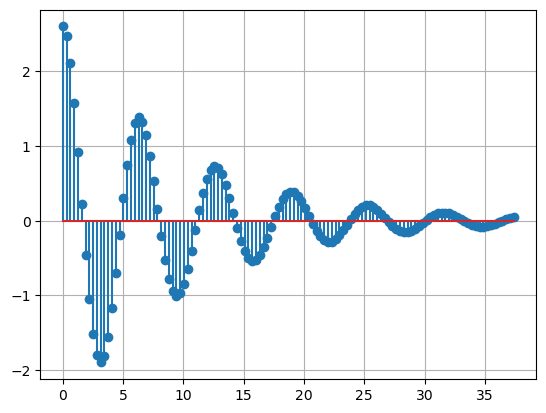

In [6]:
tvec_needed = tvec_half[0:120]
Ryy_needed = Ryy_half[0:120]

plt.stem(tvec_needed, Ryy_needed)
plt.grid()

Realization of white noise

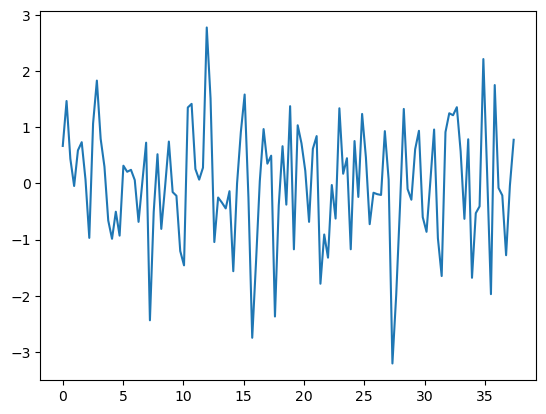

In [7]:
white_noise = stats.norm.rvs(size=120)

plt.plot(tvec_needed, white_noise)

In [8]:
def construct(row, shift):
    N = len(row)
    row2 = row[0:N-shift]
    row1 = []
    
    for count in np.arange(shift, 0, -1): 
        row1.append(row[count])
        
        
    row1 = np.array(row1)
    ans = np.concatenate((row1, row2))
    return np.array(ans)

def construct_matrix(x):
    '''To construct the covariance matrix'''
    N = len(x)
    row0 = x
    row1 = construct(x, 1)
    ans =np.array((row0, row1))
    
    counter = np.arange(2, N, 1)
    
    for count in counter:
        junk = construct(x, count)
        junk1 = np.array([junk])
        ans = np.concatenate((ans, junk1))
    
    return ans



In [41]:
C = construct_matrix(Ryy_needed)

In [10]:
D = linalg.sqrtm(C)

In [38]:
# out = np.dot(D, white_noise)
out = D@white_noise

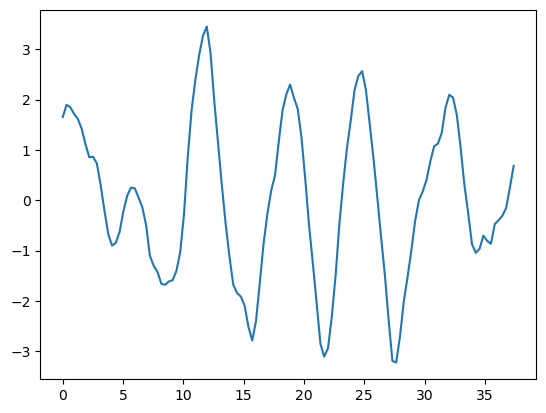

In [39]:
plt.plot(tvec_needed, out)

In [13]:
C.shape

(120, 120)

In [14]:
C[0:5, 0:5]

array([[2.598611  , 2.4695743 , 2.11235011, 1.57683227, 0.9241616 ],
       [2.4695743 , 2.598611  , 2.4695743 , 2.11235011, 1.57683227],
       [2.11235011, 2.4695743 , 2.598611  , 2.4695743 , 2.11235011],
       [1.57683227, 2.11235011, 2.4695743 , 2.598611  , 2.4695743 ],
       [0.9241616 , 1.57683227, 2.11235011, 2.4695743 , 2.598611  ]])

In [15]:
Ryy_needed[1]

2.469574296664235